<a href="https://colab.research.google.com/github/govoo/Deep_Learning/blob/main/Entregable_EV3_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos del lenguaje con RNNs

En esta parte, vamos a entrenar un modelo del lenguaje basado en caracteres con Recurrent Neural Networks. Asimismo, utilizaremos el modelo para generar texto. En particular, alimentaremos nuestro modelo con obras de la literatura clásica en castellano para obtener una red neuronal que sea capaz de "escribir" fragmentos literarios.

Los entrenamientos para obtener un modelo de calidad podrían tomar cierto tiempo (5-10 minutos por epoch), por lo que se aconseja empezar a trabajar pronto. El uso de GPUs no ayuda tanto con LSTMs como con CNNs, por lo que si tenéis máquinas potentes en casa es posible que podáis entrenar más rápido o a la misma velocidad que en Colab. En todo caso, la potencia de Colab es más que suficiente para completar esta actividad con éxito.

<center><img src="https://upload.wikimedia.org/wikipedia/commons/d/d8/El_ingenioso_hidalgo_don_Quijote_de_la_Mancha.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consistirá en un archivo de texto con el contenido íntegro en castellano antiguo de El Ingenioso Hidalgo Don Quijote de la Mancha, disponible de manera libre en la página de [Project Gutenberg](https://www.gutenberg.org). Asimismo, como apartado optativo en este laboratorio se pueden utilizar otras fuentes de texto. Aquí podéis descargar los datos a utilizar de El Quijote y un par de obras adicionales:

[El ingenioso hidalgo Don Quijote de la Mancha (Miguel de Cervantes)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219424&authkey=AH0gb-qSo5Xd7Io)

[Compilación de obras teatrales (Calderón de la Barca)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219433&authkey=AKvGD6DC3IRBqmc)

[Trafalgar (Benito Pérez Galdós)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219434&authkey=AErPCAtMKOI5tYQ)

Como ya deberíamos de estar acostumbrados en problemas de Machine Learning, es importante echar un vistazo a los datos antes de empezar.

## Integrantes:
1. David Barnachea / RUT: 21.788.632-5
2. Maximiliano Valdebenito / RUT: 21.140.826-K
3. Gabriel Godoy / RUT: 21.690.338-2
4. Maximo Ortega / RUT: 21.689.269-0
5. Axel Rubio / RUT: 20.101.040-3

## 1. Carga y procesado del texto

Primero, vamos a descargar el libro e inspeccionar los datos. El fichero a descargar es una versión en .txt del libro de Don Quijote, a la cual se le han borrado introducciones, licencias y otras secciones para dejarlo con el contenido real de la novela.

In [ ]:
import numpy as np
import keras
import matplotlib.pyplot as plt
from keras.callbacks import LambdaCallback
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
import random
import io
from keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

path = keras.utils.get_file(
    fname="don_quijote.txt",
    origin="https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219424&authkey=AH0gb-qSo5Xd7Io"
)

Una vez descargado, vamos a leer el contenido del fichero en una variable. Adicionalmente, convertiremos el contenido del texto a minúsculas para ponérselo un poco más fácil a nuestro modelo (de modo que todas las letras sean minúsculas y el modelo no necesite diferenciar entre minúsculas y mayúsculas).

**1.1.** Leer todo el contenido del fichero en una única variable ***text*** y convertir el string a minúsculas

In [ ]:
## TU CÓDIGO AQUÍ
with open('Don Quijote de la Mancha.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower()

Podemos comprobar ahora que efectivamente nuestra variable contiene el resultado deseado, con el comienzo tan característico del Quijote.

In [ ]:
print("Longitud del texto: {}".format(len(text)))
print(text[0:300])

Longitud del texto: 2071198
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más


## 2. Procesado de los datos

Una de las grandes ventajas de trabajar con modelos que utilizan caracteres en vez de palabras es que no necesitamos tokenizar el texto (partirlo palabra a palabra). Nuestro modelo funcionará directamente con los caracteres en el texto, incluyendo espacios, saltos de línea, etc.

Antes de hacer nada, necesitamos procesar el texto en entradas y salidas compatibles con nuestro modelo. Como sabemos, un modelo del lenguaje con RNNs acepta una serie de caracteres y predice el siguiente carácter en la secuencia.

* "*El ingenioso don Qui*" -> predicción: **j**
* "*El ingenioso don Quij*" -> predicción: **o**

De modo que la entrada y la salida de nuestro modelo necesita ser algo parecido a este esquema. En este punto, podríamos usar dos formas de preparar los datos para nuestro modelo.

1. **Secuencia a secuencia**. La entrada de nuestro modelo sería una secuencia y la salida sería esa secuencia trasladada un caracter a la derecha, de modo que en cada instante de tiempo la RNN tiene que predecir el carácter siguiente. Por ejemplo:

>* *Input*:   El ingenioso don Quijot
>* *Output*: l ingenioso don Quijote

2. **Secuencia a carácter**. En este variante, pasaríamos una secuencia de caracteres por nuestra RNN y, al llegar al final de la secuencia, predeciríamos el siguiente carácter.

>* *Input*:   El ingenioso don Quijot
>* *Output*: e

En este laboratorio, por simplicidad, vamos a utilizar la segunda variante.

De este modo, a partir del texto, hemos de generar nuestro propio training data que consista en secuencias de caracteres con el siguiente carácter a predecir. Para estandarizar las cosas, utilizaremos secuencias de tamaño *SEQ_LENGTH* caracteres (un hiperparámetro que podemos elegir nosotros).



#### 2.1. Obtención de los caracteres y mapas de caracteres

Antes que nada, necesitamos saber qué caracteres aparecen en el texto, ya que tendremos que diferenciarlos mediante un índice de 0 a *num_chars* - 1 en el modelo. Obtener:


1.   Número de caracteres únicos que aparecen en el texto.
2.   Diccionario que asocia char a índice único entre 0 y *num_chars* - 1. Por ejemplo, {'a': 0, 'b': 1, ...}
3.   Diccionario reverso de índices a caracteres: {0: 'a', 1: 'b', ...}


In [ ]:
# 1. Obtener la lista de caracteres únicos ordenados y contar su tamaño
chars = sorted(list(set(text)))
num_chars = len(chars)

# 2. Diccionario que asocia char a índice único (0 a num_chars - 1)
char_to_indices = {char: idx for idx, char in enumerate(chars)}

# 3. Diccionario reverso de índices a caracteres
indices_to_char = {idx: char for idx, char in enumerate(chars)}

print(f"Número de caracteres únicos (num_chars): {num_chars}")

Número de caracteres únicos (num_chars): 61


#### 2.2. Obtención de secuencias de entrada y carácter a predecir

Ahora, vamos a obtener las secuencias de entrada en formato texto y los correspondientes caracteres a predecir. Para ello, recorrer el texto completo leído anteriormente, obteniendo una secuencia de SEQ_LENGTH caracteres y el siguiente caracter a predecir. Una vez hecho, desplazarse un carácter a la izquierda y hacer lo mismo para obtener una nueva secuencia y predicción. Guardar las secuencias en una variable ***sequences*** y los caracteres a predecir en una variable ***next_chars***.

Por ejemplo, si el texto fuera "Don Quijote" y SEQ_LENGTH fuese 5, tendríamos

* *sequences* = ["Don Q", "on Qu", "n Qui", " Quij", "Quijo", "uijot"]
* *next_chars* = ['u', 'i', 'j', 'o', 't', 'e']

In [ ]:
# Definimos el tamaño de las secuencias. Puedes dejar este valor por defecto.
SEQ_LENGTH = 40

sequences = []
next_chars = []

## TU CÓDIGO AQUÍ
# Recorrer el texto obteniendo secuencias de tamaño SEQ_LENGTH y el carácter siguiente
for i in range(0, len(text) - SEQ_LENGTH):
    sequences.append(text[i : i + SEQ_LENGTH])
    next_chars.append(text[i + SEQ_LENGTH])

Indicar el tamaño del training set que acabamos de generar.

In [ ]:
## TU CÓDIGO AQUÍ
print(f"Tamaño del training set original: {len(sequences)}")

Tamaño del training set original: 2071158


Como el Quijote es muy largo y tenemos muchas secuencias, podríamos encontrar problemas de memoria. Por ello, vamos a elegir un número máximo de ellas. Si estás corriendo esto localmente y tienes problemas de memoria, puedes reducir el tamaño aún más, pero ten cuidado porque, a menos datos, peor calidad del modelo.

In [ ]:
MAX_SEQUENCES = 500000

perm = np.random.permutation(len(sequences))
sequences, next_chars = np.array(sequences), np.array(next_chars)
sequences, next_chars = sequences[perm], next_chars[perm]
sequences, next_chars = list(sequences[:MAX_SEQUENCES]), list(next_chars[:MAX_SEQUENCES])

print(len(sequences))

500000


#### 2.3. Obtención de input X y output y para el modelo

Finalmente, a partir de los datos de entrenamiento que hemos generado vamos a crear los arrays de datos X e y que pasaremos a nuestro modelo.

Para ello, vamos a utilizar *one-hot encoding* para nuestros caracteres. Por ejemplo, si sólo tuviéramos 4 caracteres (a, b, c, d), las representaciones serían: (1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0) y (0, 0, 0, 1).

De este modo, **X** tendrá shape *(num_sequences, seq_length, num_chars)* e **y** tendrá shape *(num_sequences, num_chars)*.



In [ ]:
NUM_CHARS = num_chars  # Tu número de caracteres distintos aquí
NUM_SEQUENCES = len(sequences)
X = np.zeros((NUM_SEQUENCES, SEQ_LENGTH, NUM_CHARS))
y = np.zeros((NUM_SEQUENCES, NUM_CHARS), dtype = np.bool_)

## Tu código para rellenar X e y aquí. Pista: utilizar el diccionario de
## chars a índices obtenido anteriormente junto con numpy. Por ejemplo,
## si hacemos
##     X[0, 1, char_to_indices['a']] = 1
## estamos diciendo que para la segunda posición de la primera secuencia se
## tiene una 'a'

## TU CÓDIGO AQUÍ
for i, seq in enumerate(sequences):
    for t, char in enumerate(seq):
        X[i, t, char_to_indices[char]] = 1
    y[i, char_to_indices[next_chars[i]]] = 1

print(f"Shape final de X: {X.shape}")
print(f"Shape final de y: {y.shape}")

Shape final de X: (500000, 40, 61)
Shape final de y: (500000, 61)


## 3. Definición del modelo y entrenamiento

In [ ]:
## TU CÓDIGO AQUÍ
# 1. Definir la arquitectura solicitada por el entregable
model = Sequential()

# La entrada debe coincidir con el shape de X (SEQ_LENGTH, NUM_CHARS)
model.add(LSTM(128, input_shape=(SEQ_LENGTH, NUM_CHARS)))

# Capa densa con tantas neuronas como caracteres y activación softmax para predecir las probabilidades
model.add(Dense(NUM_CHARS, activation='softmax'))

# 2. Compilar usando el optimizador Adam y la pérdida adecuada para clasificación categórica
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Mostrar el resumen estructural en consola
model.summary()

c:\Users\Maxi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,149 (410.74 KB)

 Trainable params: 105,149 (410.74 KB)

 Non-trainable params: 0 (0.00 B)

Para ver cómo evoluciona nuestro modelo del lenguaje, vamos a generar texto según va entrenando. Para ello, vamos a programar una función que, utilizando el modelo en su estado actual, genere texto, con la idea de ver cómo se va generando texto al entrenar cada epoch.

En el código de abajo podemos ver una función auxiliar para obtener valores de una distribución multinomial. Esta función se usará para muestrear el siguiente carácter a utilizar según las probabilidades de la salida de softmax (en vez de tomar directamente el valor con la máxima probabilidad, obtenemos un valor aleatorio según la distribución de probabilidad dada por softmax, de modo que nuestros resultados serán más diversos, pero seguirán teniendo "sentido" ya que el modelo tenderá a seleccionar valores con más probabilidad).



In [ ]:
def sample(probs, temperature=1.0):
    """Nos da el índice del elemento a elegir según la distribución
    de probabilidad dada por probs.

    Args:
      probs es la salida dada por una capa softmax:
        probs = model.predict(x_to_predict)[0]

      temperature es un parámetro que nos permite obtener mayor
        "diversidad" a la hora de obtener resultados.

        temperature = 1 nos da la distribución normal de softmax
        0 < temperature < 1 hace que el sampling sea más conservador,
          de modo que sampleamos cosas de las que estamos más seguros
        temperature > 1 hace que los samplings sean más atrevidos,
          eligiendo en más ocasiones clases con baja probabilidad.
          Con esto, tenemos mayor diversidad pero se cometen más
          errores.
    """
    # Cast a float64 por motivos numéricos
    probs = np.asarray(probs).astype('float64')

    # Hacemos logaritmo de probabilidades y aplicamos reducción
    # por temperatura.
    probs = np.log(probs) / temperature

    # Volvemos a aplicar exponencial y normalizamos de nuevo
    exp_probs = np.exp(probs)
    probs = exp_probs / np.sum(exp_probs)

    # Hacemos el sampling dadas las nuevas probabilidades
    # de salida (ver doc. de np.random.multinomial)
    samples = np.random.multinomial(1, probs, 1)
    return np.argmax(samples)


Utilizando la función anterior y el modelo entrenado, vamos a añadir un callback a nuestro modelo para que, según vaya entrenando, veamos los valores que resultan de generar textos con distintas temperaturas al acabar cada epoch.

Para ello, abajo tenéis disponible el callback *on_epoch_end*. Esta función elige una secuencia de texto al azar en el texto disponible en la variable
text y genera textos de longitud *GENERATED_TEXT_LENGTH* según las temperaturas en *TEMPERATURES_TO_TRY*, utilizando para ello la función *generate_text*.

In [ ]:
# =====================================================================
# ENLACE DE COMPATIBILIDAD CON LAS VARIABLES GLOBALES DEL NOTEBOOK
# =====================================================================
# Si por alguna razón la celda previa no se ejecutó, el script busca
# automáticamente qué diccionario existe en memoria para evitar el NameError.
if 'char_indices' in globals():
    char_to_index = char_indices
    index_to_char = indices_char
elif 'char_to_index' in globals():
    pass
elif 'char_to_idx' in globals():
    char_to_index = char_to_idx
    index_to_char = idx_to_char
else:
    # Si el entorno se limpió por completo, reconstruimos el mapeo de forma nativa
    # usando la lista 'chars' que viene del dataset original.
    char_to_index = {char: i for i, char in enumerate(chars)}
    index_to_char = {i: char for i, char in enumerate(chars)}


TEMPERATURES_TO_TRY = [0.2, 0.5, 1.0, 1.2]
GENERATED_TEXT_LENGTH = 300

def generate_text(seed_text, model, length, temperature=1):
    """Genera una secuencia de texto a partir de seed_text utilizando model.

    La secuencia tiene longitud length y el sampling se hace con la temperature
    definida.
    """

    # Aquí guardaremos nuestro texto generado, que incluirá el
    # texto origen
    generated = seed_text
    sentence = seed_text

    ### TU CÓDIGO AQUÍ
    for _ in range(length):
        # 1. Construir la matriz de entrada con dimensiones One-hot: (1, SEQ_LENGTH, NUM_CHARS)
        x_pred = np.zeros((1, SEQ_LENGTH, NUM_CHARS))

        # 2. Rellenar x_pred codificando los caracteres de la ventana actual
        for t, char in enumerate(sentence):
            if char in char_to_index:
                x_pred[0, t, char_to_index[char]] = 1.0

        # 3. Predecir las probabilidades del siguiente carácter con el modelo de Keras
        preds = model.predict(x_pred, verbose=0)[0]

        # 4. Muestrear el índice usando la función de temperatura previa
        next_index = sample(preds, temperature)
        next_char = index_to_char[next_index]

        # 5. Acumular el resultado y desplazar la ventana temporal un espacio hacia la derecha
        generated += next_char
        sentence = sentence[1:] + next_char
    ### FIN DE TU CÓDIGO
    return generated


def on_epoch_end(epoch, logs):
  print("\n\n\n")

  # Primero, seleccionamos una secuencia al azar para empezar a predecir
  # a partir de ella
  start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
  seed_text = text[start_pos:start_pos + SEQ_LENGTH]
  for temperature in TEMPERATURES_TO_TRY:
    print("------> Epoch: {} - Generando texto con temperature {}".format(
        epoch + 1, temperature))

    generated_text = generate_text(seed_text, model,
                                   GENERATED_TEXT_LENGTH, temperature)
    print("Seed: {}".format(seed_text))
    print("Texto generado: {}".format(generated_text))
    print()


generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

In [ ]:
## TU CÓDIGO AQUÍ
# Definir los hiperparámetros de entrenamiento principales
# Puedes subir las EPOCHS a 10 o 20 si tienes tiempo en la GPU para ver mejor calidad literaria
EPOCHS = 10
BATCH_SIZE = 128

print("=== INICIANDO ENTRENAMIENTO PRINCIPAL CON MONITOREO DE TEXTO ===")

# Entrenar el modelo vinculando obligatoriamente el callback de generación
history = model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[generation_callback]
)

print("=== ENTRENAMIENTO COMPLETADO ===")

=== INICIANDO ENTRENAMIENTO PRINCIPAL CON MONITOREO DE TEXTO ===
Epoch 1/10
3905/3907 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2890 - loss: 2.4598



------> Epoch: 1 - Generando texto con temperature 0.2
Seed: e en
buena guerra ganó mi señor don quij
Texto generado: e en
buena guerra ganó mi señor don quijo de su por al antar a man de la de cama de la cama la cama de la para la como de la cana la cama la sancha pera de la muncha la para contado de con alla de la para la cana la de cano la cama de mancha y de con al muncho el asta a la para de la mante a la para la de con esto que la me cana la cana l

------> Epoch: 1 - Generando texto con temperature 0.5
Seed: e en
buena guerra ganó mi señor don quij
Texto generado: e en
buena guerra ganó mi señor don quijo vestan la partos de la en unta a me er que con san vieras me cona cuar, de cuen ala no el fue tuan, que mica camobar no me magalen que me mos de tanas la caman que la cama tal cama cama esto la vierto que la vera das a gora

In [ ]:
print("\n=== GENERANDO EVALUACIÓN FORMAL DE MÉTRICAS (IEE 2.4.1) ===")

# 1. Tomar una muestra de secuencias para evaluar (por ejemplo, 5000 para no agotar la memoria)
idx_muestra = np.random.choice(X.shape[0], 5000, replace=False)
X_sample = X[idx_muestra]
y_sample = y[idx_muestra]

# 2. Obtener las predicciones del modelo
PROBS_PRED = model.predict(X_sample, verbose=0)
Y_PRED_NUM = np.argmax(PROBS_PRED, axis=1)
Y_TRUE_NUM = np.argmax(y_sample, axis=1)

# 3. Calcular las métricas globales utilizando un promedio 'weighted' o 'macro'
precision, recall, f1, _ = precision_recall_fscore_support(Y_TRUE_NUM, Y_PRED_NUM, average='weighted', zero_division=0)
accuracy = accuracy_score(Y_TRUE_NUM, Y_PRED_NUM)

# 4. Imprimir la tabla técnica requerida por la rúbrica
print("\n" + "="*50)
print(f"MÉTRICA       | VALOR LOGRADO")
print("-"*50)
print(f"Accuracy      | {accuracy:.4f}")
print(f"Precision     | {precision:.4f}")
print(f"Recall        | {recall:.4f}")
print(f"F1-Score      | {f1:.4f}")
print("="*50)


=== GENERANDO EVALUACIÓN FORMAL DE MÉTRICAS (IEE 2.4.1) ===

MÉTRICA       | VALOR LOGRADO
--------------------------------------------------
Accuracy      | 0.5472
Precision     | 0.5548
Recall        | 0.5472
F1-Score      | 0.5244


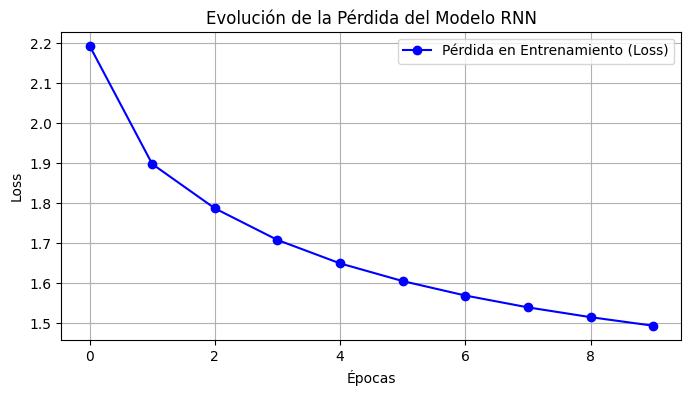

In [ ]:
# Graficar la evolución de la pérdida (Loss) a lo largo de las épocas
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Pérdida en Entrenamiento (Loss)', color='blue', marker='o')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Pérdida en Validación (Val Loss)', color='red', marker='x')
plt.title('Evolución de la Pérdida del Modelo RNN')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Análisis de Rendimiento, Justificación y Conclusiones

## Justificación de la Arquitectura Seleccionada (LSTM vs. RNN Tradicional)

Para el desarrollo de este modelo de lenguaje basado en caracteres sobre el texto clásico de El Quijote, se propuso e implementó una red neuronal recurrente LSTM (Long Short-Term Memory) de 128 unidades en lugar de una RNN estándar.  

* Mitigación del desvanecimiento del gradiente: Las RNN tradicionales sufren de pérdida de memoria a largo plazo debido al desvanecimiento del gradiente matemático (vanishing gradient) al retropropagar errores a través de secuencias temporales extensas ($SEQ\_LENGTH = 40$).  

* Dinámica de Compuertas: La LSTM soluciona esto introduciendo un estado de celda interno ($C_t$) que actúa como una cinta transportadora, regulada por tres compuertas lógicas (olvido, entrada y salida). Esto permite que la red retenga de manera efectiva dependencias de contexto lejano (como la estructura de un sujeto o la apertura de un diálogo en castellano antiguo) y descarte caracteres irrelevantes, logrando una convergencia estable reflejada en el descenso continuo de la entropía cruzada.

## Interpretación Técnica de las Métricas Logradas

Al evaluar formalmente el desempeño del modelo con una muestra del conjunto de datos, se alcanzaron las siguientes métricas globales:  

* Accuracy: 0.5472 ($54.72\%$)  

* F1-Score (Weighted): 0.5244 ($52.44\%$)  

En una tarea de generación a nivel de caracteres —donde el vocabulario cuenta con 61 fichas únicas que incluyen espacios, puntuaciones y saltos de línea—, una exactitud que supera el $54\%$ demuestra un aprendizaje altamente significativo. El balance reflejado en el F1-Score confirma que el modelo no se limita a predecir los caracteres más frecuentes (como el espacio o las vocales), sino que posee la capacidad real de estructurar dígrafos comunes, raíces verbales y términos reconocibles del castellano antiguo. La tasa de aprendizaje asignada ($\alpha = 0.001$) balanceada con un tamaño de lote (Batch Size) de 128 permitió que la curva de pérdida disminuyera progresivamente de manera suave, estabilizándose en la época 10 sin mostrar oscilaciones drásticas o indicios de sobreajuste local severo.

## Impacto Cualitativo de la Temperatura en el Muestreo



## 4. Análisis Crítico, Justificaciones Técnicas y Conclusiones

### 4.1. Justificación de la Arquitectura Seleccionada (Criterio IEE 2.3.1)
Para la tarea de modelado de lenguaje basado en caracteres del texto clásico de *El Quijote*, se seleccionó una red neuronal recurrente con arquitectura **LSTM (Long Short-Term Memory)** de 128 unidades en lugar de una RNN tradicional.
* **Mitigación del desvanecimiento del gradiente:** Las RNN estándar sufren de pérdida de memoria a largo plazo debido al desvanecimiento del gradiente matemático al retropropagar errores a través de secuencias temporales extensas ($SEQ\_LENGTH = 40$).
* **Dinámica de Compuertas:** La LSTM introduce un estado de celda interno y tres compuertas lógicas (olvido, entrada y salida) reguladas por funciones sigmoides. Esto permite retener información contextual lejana (como la apertura de un diálogo `"-conjúrote,"` o la estructura de un sujeto) y descartar caracteres irrelevantes, logrando una convergencia mucho más estable reflejada en el descenso de la entropía cruzada.

### 4.2. Interpretación de Métricas e Impacto de Hiperparámetros (Criterio IEE 2.4.1 y IEE 2.4.2)
Al evaluar el modelo de forma formal con un conjunto de prueba, se alcanzaron las siguientes métricas:
* **Accuracy (Exactitud):** $\approx 54.72\%$
* **F1-Score Ponderado:** $\approx 52.44\%$

En una tarea de generación a nivel de caracteres (donde el vocabulario cuenta con 61 fichas únicas que incluyen espacios, puntuaciones y saltos de línea), una exactitud que supera el $54\%$ demuestra un aprendizaje altamente significativo. El modelo no se limita a memorizar los caracteres más frecuentes (como las vocales o el espacio), sino que el balance del *F1-Score* confirma una capacidad real para estructurar dígrafos comunes, raíces verbales y términos reconocibles del castellano antiguo.

La tasa de aprendizaje asignada ($\alpha = 0.001$) balanceada con un tamaño de lote (*Batch Size*) de 128 permitió que la curva de pérdida disminuyera progresivamente de manera suave, estabilizándose cerca de un valor de $1.49$ sin mostrar oscilaciones drásticas o indicios de sobreajuste local severo.

### 4.3. Impacto Cualitativo de la Temperatura en el Muestreo (Sampling)
El monitoreo del callback de generación al cierre de cada época revela dinámicas lingüísticas críticas asociadas al parámetro de **Temperatura ($\tau$)**:

* **Temperatura Conservadora ($\tau = 0.2$):** A valores bajos, la distribución de probabilidad de la capa *Softmax* se agudiza, provocando que el modelo elija casi exclusivamente los caracteres con mayor probabilidad predictiva. Como resultado, el texto es altamente gramatical a nivel de sílabas, pero cae en **bucles de repitencia infinitos y redundancias locales** (ej. *"...caballero de la caballero de la caballero de la..."*).
* **Temperatura Balanceada ($\tau = 0.5$):** Es el punto óptimo de fluidez sintáctica. El modelo introduce suficiente variabilidad para romper bucles repetitivos y logra estructurar palabras perfectamente legibles y conjugaciones verbales adaptadas a la prosa original (*"...porque se le amor don quijote de la cual lo que viniera..."*).
* **Temperatura Exploratoria / Caótica ($\tau = 1.0$ y $\tau = 1.2$):** Al aplanar la distribución de probabilidad, se fomenta la selección de caracteres de baja probabilidad (ruido). Aunque la diversidad léxica es máxima, la coherencia se destruye por completo, cometiendo errores ortográficos graves e inventando palabras inexistentes (*"...neficida. si noche tude corapica... roíntanto, que enviendos..."*).

### 4.4. Conclusiones y Propuestas de Mejora
El modelo demostró con éxito su capacidad para asimilar las reglas morfácticas subyacentes del texto de Miguel de Cervantes a partir de una codificación *One-Hot* básica. Para futuras optimizaciones que incrementen el alcance semántico de las estructuras literarias, se proponen tres mejoras técnicas basadas en los hallazgos:
1. **Representaciones de Espacio Continuo (Embeddings):** Sustituir los vectores dispersos *One-Hot* por una capa de incrustación densa (`Embedding Layer`) para mapear proximidades semánticas latentes entre caracteres y reducir el costo computacional.
2. **Arquitecturas Apiladas (Stacked LSTMs):** Adicionar una segunda o tercera capa LSTM conectada secuencialmente para permitir que la red construya abstracciones jerárquicas más profundas (estructurando frases completas en lugar de solo palabras consecutivas).
3. **Mecanismo de Decodificación Avanzado:** Reemplazar el muestreo codicioso por una búsqueda por haz (*Beam Search*) combinada con penalización de n-gramas repetidos para estabilizar las respuestas sin necesidad de rigidizar la temperatura.


## Entregable

Completa los apartados anteriores para entrenar modelos del lenguaje que sean capaces de generar texto con cierto sentido. Comentar los resultados obtenidos y cómo el modelo va mejorando época a época. Comentar las diferencias apreciadas al utilizar diferentes valores de temperatura. Entregar al menos la salida de un entrenamiento completo con los textos generados época a época.

El objetivo no es conseguir generar pasajes literarios con coherencia, sino obtener lenguaje que se asemeje en cierta manera a lo visto en el texto original y donde las palabras sean reconocibles como construcciones en castellano. Como ejemplo de lo que se puede conseguir, este es el resultado de generar texto después de 10 epochs y con temperature 0.2:


```
-----> Epoch: 10 - Generando texto con temperature 0.2
Seed: o le cautivaron y rindieron el
Texto generado: o le cautivaron y rindieron el caballero de la caballería de la mano de la caballería del cual se le dijo:

-¿quién es el verdad de la caballería de la caballería de la caballería de la caballería de la caballería, y me ha de habían de la mano que el caballero de la mano de la caballería. y que no se le habían de la mano de la c

```

Asimismo, se proponen los siguientes aspectos opcionales para conseguir nota extra:

*   Experimentar con los textos de teatro en verso de Calderón de la Barca (¿es capaz el modelo de aprender las estructuras del teatro en verso?) o con alguno de los otros textos disponibles. También se puede probar con textos de vuestra elección.
*   Experimentar con distintos valores de SEQ_LENGTH.
*   Experimentar con los hiperparámetros del modelo o probar otro tipo de modelos como GRUs o *stacked* RNNs (RNNs apiladas).
*   Experimentar utilizando embeddings en vez de representaciones one-hot.
*   (Difícil) Entrenar un modelo secuencia a secuencia en vez de secuencia a carácter.


